# Logistic Regression Model

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

### Ordinal Encoding Categorical Data

In [3]:
df = pd.read_csv('Datasets/train.csv')

def clean(df):
    df = df.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 3, 'C': 2, 'Q': 1, np.nan: -1})
    df = df.fillna(-1)
    return df

df = clean(df)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,3
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,3
3,1,1,1,35.0,1,0,53.1000,3
4,0,3,0,35.0,0,0,8.0500,3


### Splitting Dataset

In [4]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Feature Scaling

In [5]:
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Training Model

In [6]:
# Use Grid Search Cross Validation to find the optimal c parameter and features
rfe_lr = RFE(LogisticRegression(
    random_state = 1000,
    solver = 'lbfgs',
    max_iter=5000
))
grid = GridSearchCV(
    estimator = rfe_lr,
    param_grid = {"n_features_to_select": [1, 2, 3, 4, 5, 6, 7],
                  "estimator__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
                  }
)

grid = grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print(grid.best_params_)
pd.DataFrame(grid.cv_results_).head(10)

{'estimator__C': 0.01, 'n_features_to_select': 6}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__C,param_n_features_to_select,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008514,0.005625,0.000423,0.000096,0.0001,1,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
1,0.004010,0.000227,0.000287,0.000021,0.0001,2,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
2,0.003089,0.000063,0.000250,0.000012,0.0001,3,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
3,0.002627,0.000127,0.000275,0.000023,0.0001,4,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
4,0.002004,0.000097,0.000275,0.000043,0.0001,5,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
5,0.001376,0.000025,0.000247,0.000011,0.0001,6,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
6,0.000754,0.000015,0.000238,0.000005,0.0001,7,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
7,0.003726,0.000122,0.000247,0.000015,0.0010,1,"{'estimator__C': 0.001, 'n_features_to_select'...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
8,0.003269,0.000049,0.000232,0.000011,0.0010,2,"{'estimator__C': 0.001, 'n_features_to_select'...",0.615385,0.615385,0.612676,0.619718,0.619718,0.616576,0.002749,41
9,0.002772,0.000073,0.000238,0.000008,0.0010,3,"{'estimator__C': 0.001, 'n_features_to_select'...",0.629371,0.622378,0.633803,0.633803,0.633803,0.630631,0.004470,40


### Test model on test data

In [7]:
from sklearn.metrics import accuracy_score

test_predict = best_model.predict(X_test)
score = accuracy_score(y_test, test_predict)
print(score)

0.7877094972067039


In [8]:
# Use the best model to predict the test data

df_test = pd.read_csv("Datasets/test.csv")
passenger = df_test['PassengerId']
df_test = clean(df_test)
df_test = scaler.transform(df_test)
prediction = best_model.predict(df_test)

results = pd.DataFrame({"PassengerId": passenger, "Survived": prediction})
results.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [9]:
results.to_csv('Datasets/LogisticRegression.csv', index = False)

# Decision Tree Model

In [10]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(criterion='gini',
                                       random_state=1000)

grid_dt = GridSearchCV(
    estimator= decision_tree,
    param_grid= {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
)

grid_dt = grid_dt.fit(X_train, y_train)
best_model_dt = grid_dt.best_estimator_

print(grid_dt.best_params_)
pd.DataFrame(grid_dt.cv_results_).head(10)

{'max_depth': 8}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000582,0.000229,0.000232,3.566729e-05,2,{'max_depth': 2},0.755245,0.734266,0.774648,0.802817,0.816901,0.776775,0.030211,11
1,0.000487,0.000004,0.000200,1.417739e-06,3,{'max_depth': 3},0.776224,0.762238,0.830986,0.852113,0.795775,0.803467,0.033541,9
2,0.000663,0.000063,0.000262,4.086069e-05,4,{'max_depth': 4},0.748252,0.762238,0.859155,0.845070,0.809859,0.804915,0.043843,8
3,0.000565,0.000021,0.000193,6.116912e-06,5,{'max_depth': 5},0.769231,0.783217,0.852113,0.845070,0.823944,0.814715,0.033064,3
4,0.000575,0.000009,0.000184,8.449576e-07,6,{'max_depth': 6},0.727273,0.790210,0.852113,0.852113,0.830986,0.810539,0.047374,5
5,0.000615,0.000031,0.000209,4.592103e-05,7,{'max_depth': 7},0.790210,0.804196,0.845070,0.838028,0.816901,0.818881,0.020465,2
6,0.000631,0.000013,0.000191,5.244342e-06,8,{'max_depth': 8},0.783217,0.790210,0.859155,0.852113,0.823944,0.821728,0.031001,1
7,0.000634,0.000010,0.000186,3.572780e-06,9,{'max_depth': 9},0.783217,0.783217,0.859155,0.802817,0.816901,0.809061,0.028092,6
8,0.000606,0.000024,0.000170,4.839369e-06,10,{'max_depth': 10},0.776224,0.769231,0.873239,0.788732,0.809859,0.803457,0.037525,10
9,0.000631,0.000022,0.000179,1.252422e-05,11,{'max_depth': 11},0.790210,0.790210,0.859155,0.795775,0.823944,0.811859,0.026755,4


In [11]:
test_predict = best_model_dt.predict(X_test)
score = accuracy_score(y_test, test_predict)
print(score)

0.770949720670391


### Visualize Decision Tree

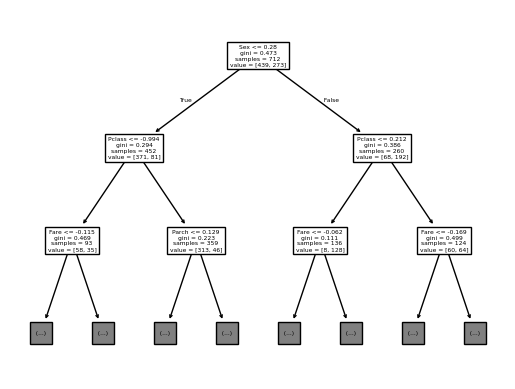

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt

tree.plot_tree(best_model_dt, max_depth=2, feature_names= X.columns)
plt.show()


### Predicting Kaggle Testing Data

In [13]:
kaggle_dt_pred = best_model_dt.predict(df_test)

results = pd.DataFrame({"PassengerId": passenger, "Survived": kaggle_dt_pred})
results.head(10)
results.to_csv('Datasets/Decision_Tree.csv', index=False)

# Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=1000)
RFC = RFC.fit(X_train, y_train)
RFC_Predict = RFC.predict(df_test)

results = pd.DataFrame({"PassengerId": passenger, "Survived": RFC_Predict})
results.to_csv('Datasets/RandomForest.csv', index=False)

# Principal Component Analysis and K Nearest Neighbors

In [ ]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

decomposition = PCA(n_components=2)
pca = decomposition.fit_transform(X_train)
pca_df = pd.DataFrame(data=pca, columns=['PCA1', 'PCA2'])

knn = KNeighborsClassifier(n_neighbors=5, p=2, metric= 'euclidean')
knn = knn.fit(pca_df, y_train)
test_decomp = decomposition.fit_transform(df_test)
knn.predict(test_decomp)


/Users/kylepham/Projects/Kaggle/Titanic_Kaggle_Comp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,